In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('/content/test.csv')
df = pd.read_csv('/content/train.csv')
df.head()
df.info()
df.describe()
df['fake'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


,count
fake,
0,288
1,288


In [3]:
df.isnull().sum()
df.dropna(inplace=True)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('fake', axis=1))

<Axes: xlabel='fake', ylabel='count'>

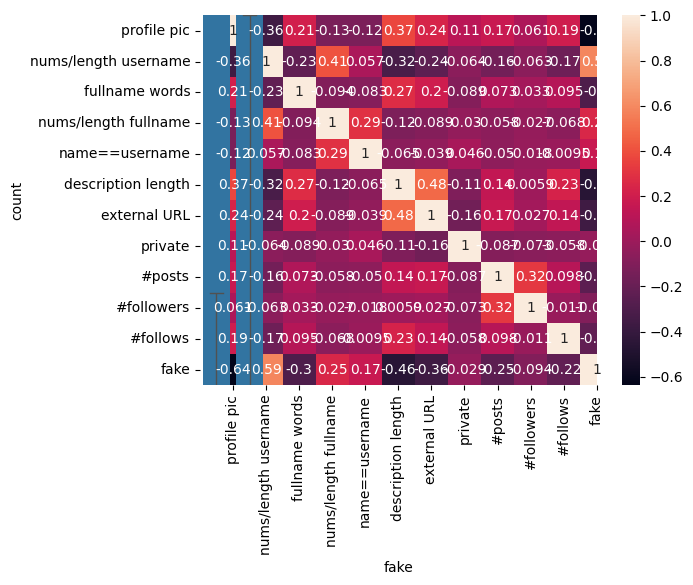

In [8]:
sns.heatmap(df.corr(), annot=True)
sns.countplot(x='fake', data=df)
sns.boxplot(x='fake', y='#followers', data=df)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['fake'], test_size=0.2, random_state=42)


In [10]:
lr = LogisticRegression()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [11]:
for model in (lr, rf):
    preds = model.predict(X_test)
    print(model.__class__.__name__,
          classification_report(y_test, preds),
          "ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


LogisticRegression               precision    recall  f1-score   support

           0       0.82      0.95      0.88        63
           1       0.93      0.75      0.83        53

    accuracy                           0.86       116
   macro avg       0.88      0.85      0.86       116
weighted avg       0.87      0.86      0.86       116
 ROC AUC: 0.9487870619946092
RandomForestClassifier               precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.94      0.87      0.90        53

    accuracy                           0.91       116
   macro avg       0.92      0.91      0.91       116
weighted avg       0.92      0.91      0.91       116
 ROC AUC: 0.9775381850853548
